# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /Users/adityabhagwani/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(".")

print("Done.")


Done.


## 3. Load the Data

In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    X_train = pd.read_csv(f"{root_dir}/train/X_train.txt", sep=r'\s+', header=None).values.astype(np.float32)
    y_train = pd.read_csv(f"{root_dir}/train/y_train.txt", sep=r'\s+', header=None).values.flatten().astype(np.int32)
    X_test  = pd.read_csv(f"{root_dir}/test/X_test.txt",  sep=r'\s+', header=None).values.astype(np.float32)
    y_test  = pd.read_csv(f"{root_dir}/test/y_test.txt",  sep=r'\s+', header=None).values.flatten().astype(np.int32)

    y_train = y_train - 1
    y_test  = y_test  - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes  = len(class_names)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"num_features: {num_features}")
print(f"num_classes:  {num_classes}")


X_train: (7352, 561)  y_train: (7352,)
X_test:  (2947, 561)   y_test:  (2947,)
num_features: 561
num_classes:  6


## 4. Quick Inspection

In [4]:
summary_df = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name":  class_names,
    "Train Samples": [np.sum(y_train == i) for i in range(num_classes)]
})

print(summary_df.to_string(index=False))

 Class Index         Class Name  Train Samples
           0            WALKING           1226
           1   WALKING_UPSTAIRS           1073
           2 WALKING_DOWNSTAIRS            986
           3            SITTING           1286
           4           STANDING           1374
           5             LAYING           1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [5]:
def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)


Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1398 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1150 - accuracy: 0.9572 - val_loss: 0.2550 - val_accuracy: 0.9164
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0916 - accuracy: 0.9636 - val_loss: 0.1449 - val_accuracy: 0.9422
Epoch 5/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0873 - accuracy: 0.9657 - val_loss: 0.2036 - val_accuracy: 0.9259
Epoch 6/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0743 - accuracy: 0.9696 - val_loss: 0.1790 - val_accuracy: 0.9388
Epoch 7/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0662 - accuracy: 0.9747 - val_loss: 0.1292 - val_accuracy: 0.9483
Epoch 8/40
92/92 [==

### Training Curves

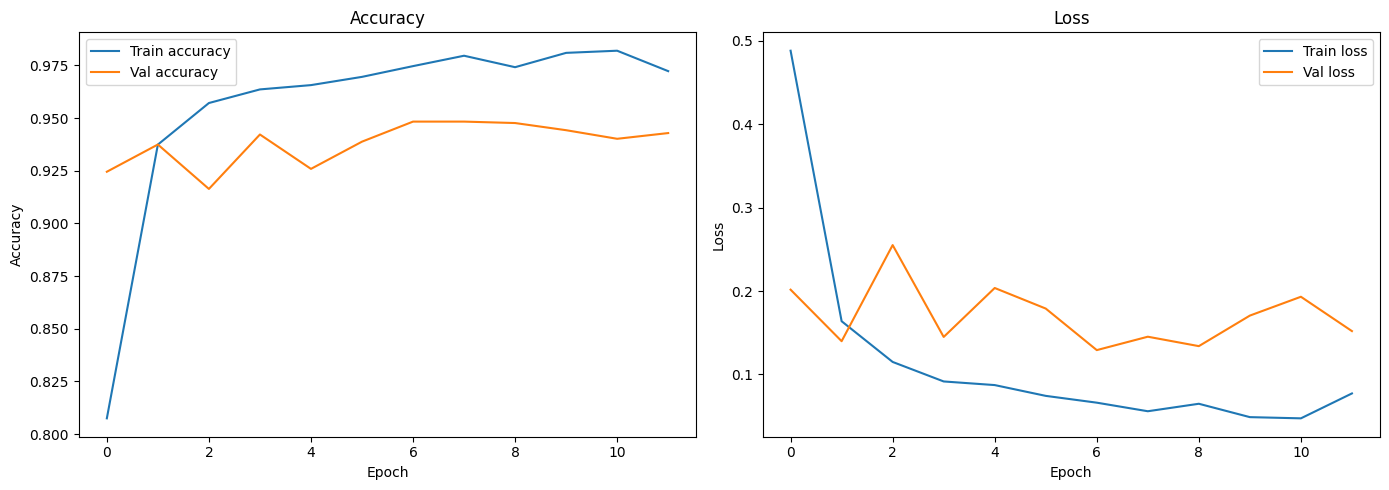

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train loss')
axes[1].plot(history.history['val_loss'], label='Val loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 491us/step
Test accuracy: 0.9332

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.96      0.98      0.97       496
  WALKING_UPSTAIRS       0.86      0.97      0.92       471
WALKING_DOWNSTAIRS       0.99      0.83      0.90       420
           SITTING       0.94      0.88      0.91       491
          STANDING       0.88      0.95      0.91       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



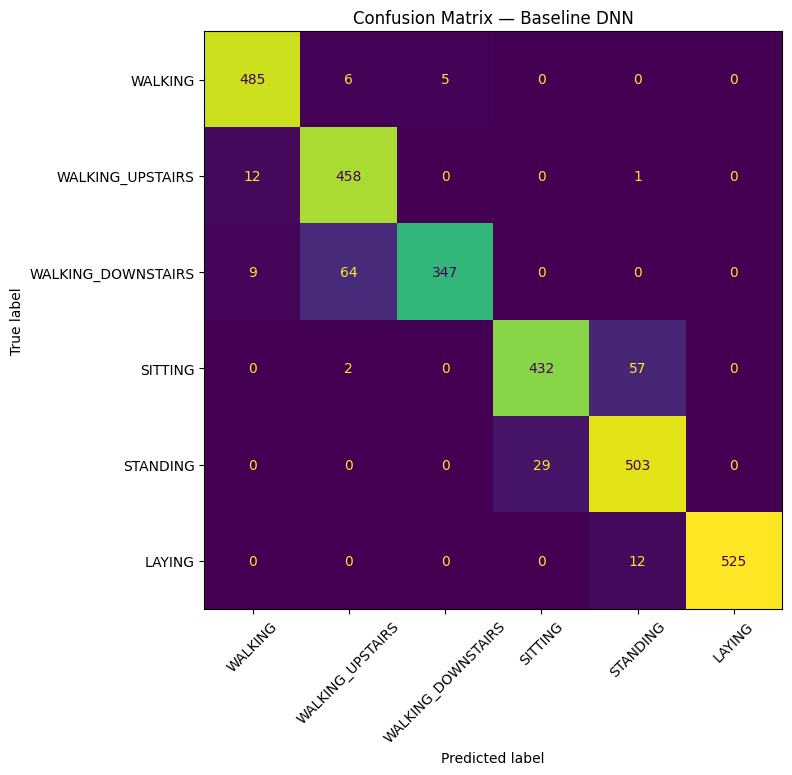

In [8]:
y_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix — Baseline DNN")
plt.tight_layout()
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [9]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details  = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale,  input_zero_point  = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]
    y_pred = []
    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] in (np.int8, np.uint8):
            x = (x / input_scale + input_zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


## 8. Convert the Baseline Model to TensorFlow Lite

In [10]:
fp32_model = convert_to_tflite_fp32(baseline_model)

fp32_size_kb = save_binary_model(fp32_model, "model_fp32.tflite")
fp32_acc, _  = evaluate_tflite_model(fp32_model, X_test, y_test)

print(f"FP32 TFLite — Size: {fp32_size_kb:.2f} KB  |  Accuracy: {fp32_acc:.4f}")


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpkj7ctvx8/assets


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpkj7ctvx8/assets
2026-05-28 02:05:56.665099: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-28 02:05:56.665242: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-28 02:05:56.667205: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpkj7ctvx8
2026-05-28 02:05:56.667712: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-28 02:05:56.667717: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpkj7ctvx8
2026-05-28 02:05:56.670333: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-05-28 02:05:56.670730: I tensorflow/cc/saved_model/load

FP32 TFLite — Size: 726.72 KB  |  Accuracy: 0.9332


## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [12]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# <-- Enter your code here <--#

# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#

steps_per_epoch = math.ceil(len(X_train) * 0.8 / batch_size)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}

pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

pruning_history = pruned_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks
)



# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#


Epoch 1/12
92/92 [==============================] - 1s 2ms/step - loss: 0.5008 - accuracy: 0.7994 - val_loss: 0.2039 - val_accuracy: 0.9266
Epoch 2/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1693 - accuracy: 0.9376 - val_loss: 0.1715 - val_accuracy: 0.9300
Epoch 3/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1273 - accuracy: 0.9537 - val_loss: 0.1516 - val_accuracy: 0.9320
Epoch 4/12
92/92 [==============================] - 0s 2ms/step - loss: 0.0977 - accuracy: 0.9670 - val_loss: 0.1429 - val_accuracy: 0.9388
Epoch 5/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1371 - accuracy: 0.9532 - val_loss: 0.1361 - val_accuracy: 0.9381
Epoch 6/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1330 - accuracy: 0.9604 - val_loss: 0.1848 - val_accuracy: 0.9313
Epoch 7/12
92/92 [==============================] - 0s 2ms/step - loss: 0.2409 - accuracy: 0.9366 - val_loss: 0.1967 - val_accuracy: 0.9354


## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [13]:
# 1. Convert pruned model (with wrappers) to FP32 TFLite
pruned_fp32_model = convert_to_tflite_fp32(pruned_model)

# 2. Save and evaluate
pruned_fp32_size_kb = save_binary_model(pruned_fp32_model, "model_pruned_fp32.tflite")
pruned_fp32_acc, _  = evaluate_tflite_model(pruned_fp32_model, X_test, y_test)
print(f"Pruned FP32     — Size: {pruned_fp32_size_kb:.2f} KB  |  Accuracy: {pruned_fp32_acc:.4f}")

# 3. Strip pruning wrappers
stripped_model = strip_pruning(pruned_model)

# 4. Convert stripped model with sparsity optimization
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
sparse_model = converter.convert()

# 5. Save and evaluate
sparse_size_kb = save_binary_model(sparse_model, "model_pruned_sparse.tflite")
sparse_acc, _  = evaluate_tflite_model(sparse_model, X_test, y_test)
print(f"Pruned Sparse   — Size: {sparse_size_kb:.2f} KB  |  Accuracy: {sparse_acc:.4f}")

INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp3fc6d4ki/assets


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp3fc6d4ki/assets
2026-05-28 02:08:35.977532: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-28 02:08:35.977799: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-28 02:08:35.978192: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp3fc6d4ki
2026-05-28 02:08:35.979736: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-28 02:08:35.979742: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp3fc6d4ki
2026-05-28 02:08:35.986554: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-28 02:08:36.019122: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned FP32     — Size: 1454.21 KB  |  Accuracy: 0.9253
INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp0u_hfxcr/assets


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp0u_hfxcr/assets


Pruned Sparse   — Size: 424.96 KB  |  Accuracy: 0.9253


2026-05-28 02:08:36.639174: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-28 02:08:36.639189: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-28 02:08:36.639284: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp0u_hfxcr
2026-05-28 02:08:36.639645: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-28 02:08:36.639649: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp0u_hfxcr
2026-05-28 02:08:36.640471: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-28 02:08:36.649049: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp0u_hfxcr
2026-05-

## 11. Part I Comparison: Accuracy and Model Size

In [14]:
part1_df = pd.DataFrame([
    {
        "Model":            "Baseline DNN",
        "Format":           "FP32 TFLite",
        "Test Accuracy":    fp32_acc,
        "Model Size (KB)":  fp32_size_kb,
    },
    {
        "Model":            "Pruned DNN (with mask)",
        "Format":           "FP32 TFLite",
        "Test Accuracy":    pruned_fp32_acc,
        "Model Size (KB)":  pruned_fp32_size_kb,
    },
    {
        "Model":            "Pruned DNN (stripped sparse)",
        "Format":           "FP32 TFLite",
        "Test Accuracy":    sparse_acc,
        "Model Size (KB)":  sparse_size_kb,
    }
])

print(part1_df.to_string(index=False))

                       Model      Format  Test Accuracy  Model Size (KB)
                Baseline DNN FP32 TFLite       0.933152       726.718750
      Pruned DNN (with mask) FP32 TFLite       0.925348      1454.214844
Pruned DNN (stripped sparse) FP32 TFLite       0.925348       424.960938


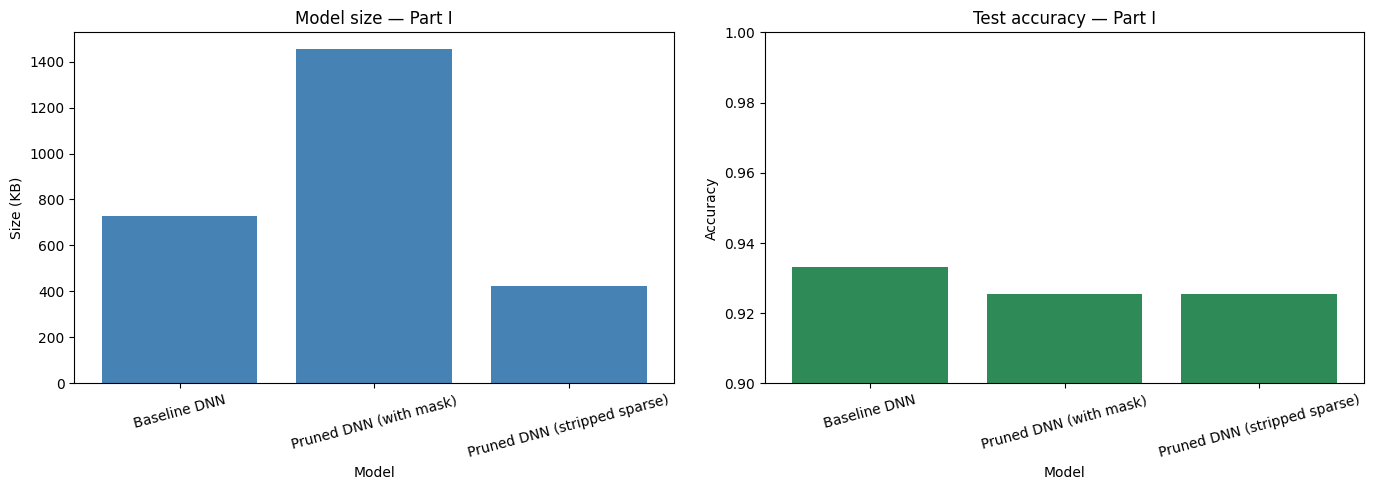

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(part1_df["Model"], part1_df["Model Size (KB)"], color='steelblue')
axes[0].set_title("Model size — Part I")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Size (KB)")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(part1_df["Model"], part1_df["Test Accuracy"], color='seagreen')
axes[1].set_title("Test accuracy — Part I")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.9, 1.0)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse Model

Classification Report (Pruned Sparse FP32):
                    precision    recall  f1-score   support

           WALKING       0.97      0.94      0.95       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.95      0.82      0.88       491
          STANDING       0.83      0.96      0.89       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



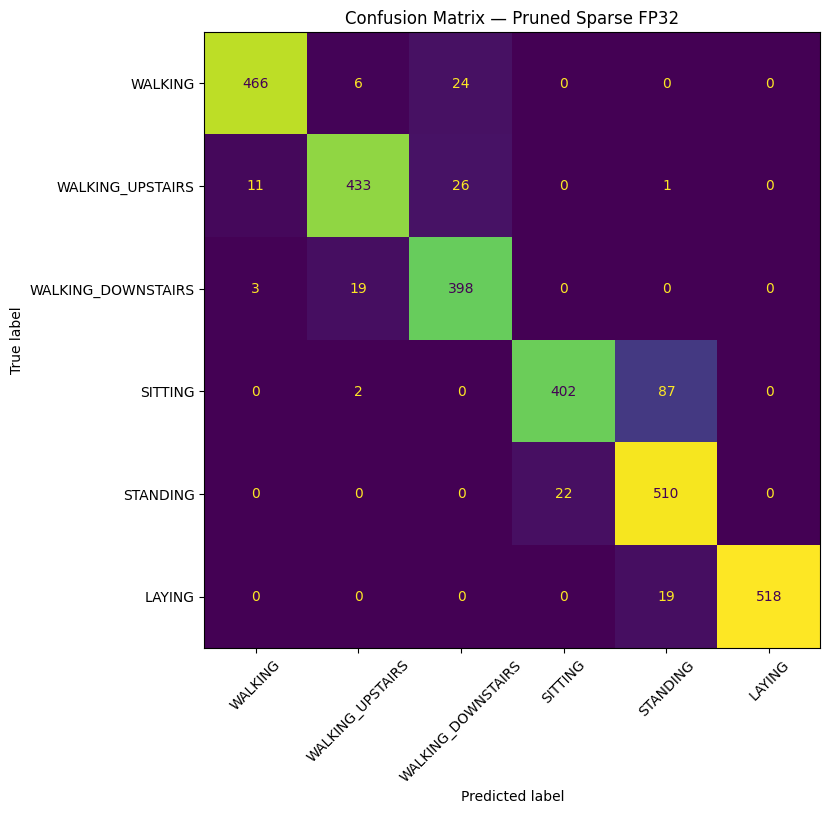

In [17]:
_, y_pred_sparse = evaluate_tflite_model(sparse_model, X_test, y_test)

print("Classification Report (Pruned Sparse FP32):")
print(classification_report(y_test, y_pred_sparse, target_names=class_names))

cm_sparse = confusion_matrix(y_test, y_pred_sparse)
disp_sparse = ConfusionMatrixDisplay(confusion_matrix=cm_sparse, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp_sparse.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix — Pruned Sparse FP32")
plt.show()


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [18]:
# 1. Convert pruned model (with mask) to float16 TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
pruned_fp16_model = converter.convert()

# 2. Save and evaluate
pruned_fp16_size_kb = save_binary_model(pruned_fp16_model, "model_pruned_fp16.tflite")
pruned_fp16_acc, _  = evaluate_tflite_model(pruned_fp16_model, X_test, y_test)
print(f"Pruned FP16 (with mask)  — Size: {pruned_fp16_size_kb:.2f} KB  |  Accuracy: {pruned_fp16_acc:.4f}")

# 3. Convert stripped sparse model to float16 TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.target_spec.supported_types = [tf.float16]
sparse_fp16_model = converter.convert()

# 4. Save and evaluate
sparse_fp16_size_kb = save_binary_model(sparse_fp16_model, "model_sparse_fp16.tflite")
sparse_fp16_acc, _  = evaluate_tflite_model(sparse_fp16_model, X_test, y_test)
print(f"Pruned Sparse FP16       — Size: {sparse_fp16_size_kb:.2f} KB  |  Accuracy: {sparse_fp16_acc:.4f}")

INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpu0egzy2a/assets


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpu0egzy2a/assets
2026-05-28 02:10:16.422856: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-28 02:10:16.422995: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-28 02:10:16.424230: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpu0egzy2a
2026-05-28 02:10:16.426116: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-28 02:10:16.426122: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpu0egzy2a
2026-05-28 02:10:16.437667: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-28 02:10:16.503022: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned FP16 (with mask)  — Size: 732.62 KB  |  Accuracy: 0.9253
INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp3xxk4qk1/assets


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp3xxk4qk1/assets


Pruned Sparse FP16       — Size: 280.01 KB  |  Accuracy: 0.9253


2026-05-28 02:10:17.110804: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-28 02:10:17.110814: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-28 02:10:17.110899: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp3xxk4qk1
2026-05-28 02:10:17.111213: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-28 02:10:17.111217: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp3xxk4qk1
2026-05-28 02:10:17.111928: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-28 02:10:17.120027: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp3xxk4qk1
2026-05-

## 12. Part II Comparison: Accuracy and Model Size

In [19]:
part2_df = pd.DataFrame([
    {
        "Model":           "Pruned (with mask)",
        "Format":          "FP32",
        "Test Accuracy":   pruned_fp32_acc,
        "Model Size (KB)": pruned_fp32_size_kb,
    },
    {
        "Model":           "Pruned Sparse (stripped)",
        "Format":          "FP32",
        "Test Accuracy":   sparse_acc,
        "Model Size (KB)": sparse_size_kb,
    },
    {
        "Model":           "Pruned (with mask)",
        "Format":          "Float16",
        "Test Accuracy":   pruned_fp16_acc,
        "Model Size (KB)": pruned_fp16_size_kb,
    },
    {
        "Model":           "Pruned Sparse (stripped)",
        "Format":          "Float16",
        "Test Accuracy":   sparse_fp16_acc,
        "Model Size (KB)": sparse_fp16_size_kb,
    },
])

print(part2_df.to_string(index=False))

                   Model  Format  Test Accuracy  Model Size (KB)
      Pruned (with mask)    FP32       0.925348      1454.214844
Pruned Sparse (stripped)    FP32       0.925348       424.960938
      Pruned (with mask) Float16       0.925348       732.625000
Pruned Sparse (stripped) Float16       0.925348       280.007812


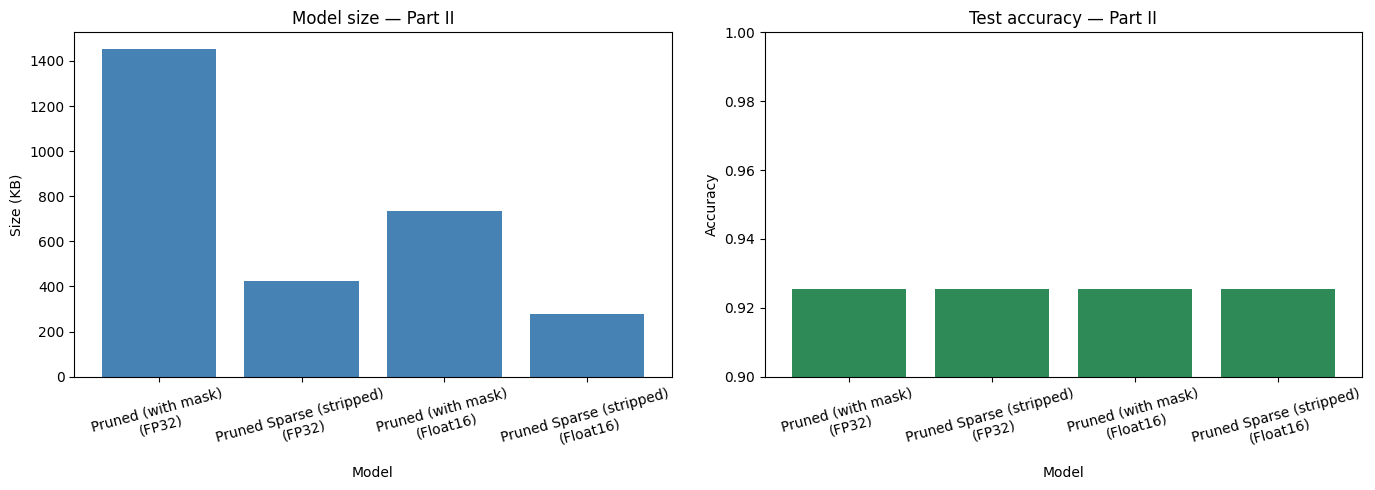

In [20]:
labels = [f"{row['Model']}\n({row['Format']})" for _, row in part2_df.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(labels, part2_df["Model Size (KB)"], color='steelblue')
axes[0].set_title("Model size — Part II")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Size (KB)")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(labels, part2_df["Test Accuracy"], color='seagreen')
axes[1].set_title("Test accuracy — Part II")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.9, 1.0)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

Classification Report (Pruned Sparse Float16):
                    precision    recall  f1-score   support

           WALKING       0.97      0.94      0.95       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.95      0.82      0.88       491
          STANDING       0.83      0.96      0.89       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



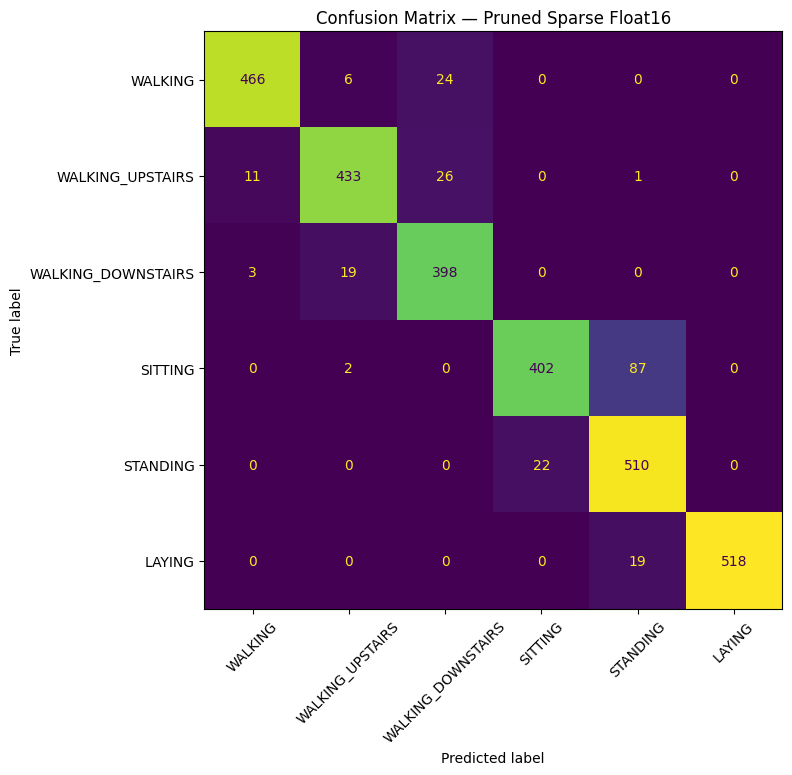

In [21]:
_, y_pred_sparse_fp16 = evaluate_tflite_model(sparse_fp16_model, X_test, y_test)

print("Classification Report (Pruned Sparse Float16):")
print(classification_report(y_test, y_pred_sparse_fp16, target_names=class_names))

cm_sparse_fp16 = confusion_matrix(y_test, y_pred_sparse_fp16)
disp_sparse_fp16 = ConfusionMatrixDisplay(confusion_matrix=cm_sparse_fp16, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp_sparse_fp16.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix — Pruned Sparse Float16")
plt.tight_layout()
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
2. Why does `strip_pruning(...)` matter before export?
3. Which model had the smallest file size in this notebook?
4. Did float16 quantization noticeably change the test accuracy?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
